In [8]:
import PcmPy as pcm
import numpy as np
import matplotlib.pyplot as plt
import globals as gl
import os
import mat73
import warnings
from lfp import make_freq_masks
from vis import plot_dissimilarities
from scipy.signal import resample

warnings.filterwarnings("ignore")

plt.style.use('default')

In [9]:
monkey = 'Pert'
path_lfp = '/cifs/pruszynski/Marco/SensoriMotorPrediction/LFPs/' #+ monkey + '/'
path_spk = '/cifs/pruszynski/Marco/SensoriMotorPrediction/spikes/' #+ monkey + '/'
cfg = mat73.loadmat(os.path.join(path_lfp,'Malfoy/cfg.PMd-19.mat'))['cfg']
foi = cfg['foi']
freq_masks = make_freq_masks(cfg)

cuePre = 0
cueIdx = 20
cuePost = 84
pertPre = cuePost + 1
pertIdx = pertPre + 30
pertPost = pertPre + 70

t_cue = np.linspace(0, cuePost - 1, cuePost)
t_pert = np.linspace(pertPre, pertPost - 1, pertPost - pertPre - 1)

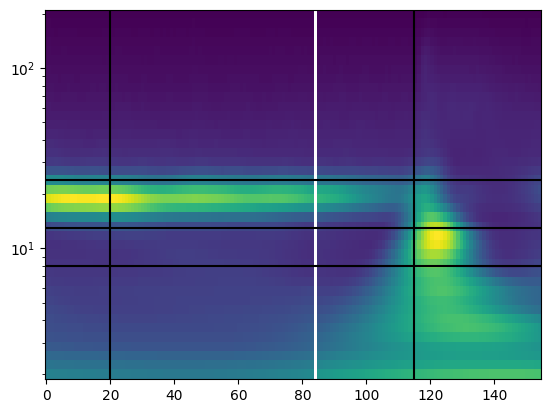

In [17]:
roi = 'S1'
rec = 15

lfp = np.load(os.path.join(path_lfp, monkey, f'lfp_aligned.{roi}-{rec}.npy'))
lfp_avg = lfp.mean(axis=(1, 3)).T

fig, ax = plt.subplots()
ax.axvline(cueIdx, color='k')
ax.axvline(pertIdx, color='k')
ax.axhline(8, color='k')
ax.axhline(13, color='k')
ax.axhline(24, color='k')

ax.pcolormesh(t_cue, foi, lfp_avg[:, :cuePost])
ax.pcolormesh(t_pert, foi, lfp_avg[:, pertPre:])
ax.set_yscale('log')


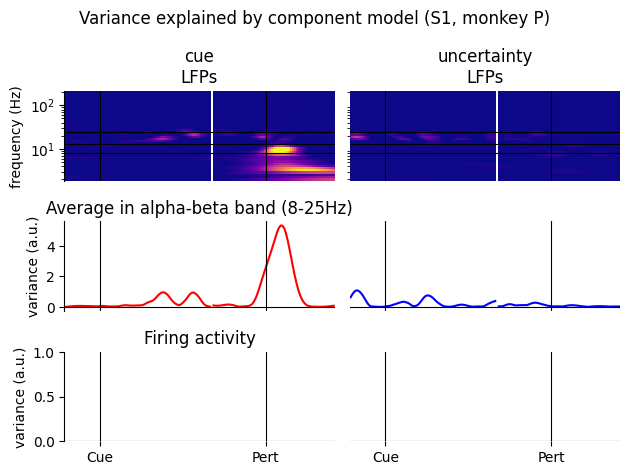

In [18]:
roi = 'S1'
epoch = 'plan'
rec = [15] #recordings[roi]
freq = freq_masks['alpha-beta']
var_expl_lfp, var_expl_spk = [], []
for r in rec:
    theta_lfp = np.load(os.path.join(path_lfp, monkey, f'theta_in.lfp.component.{monkey}.{roi}.{epoch}-{r}.npy'))
    # theta_spk = np.load(os.path.join(path_spk, monkey, f'theta_in.spike.component.{monkey}.{roi}.aligned.{epoch}-{r}.npy'))
    var_expl_lfp.append(np.exp(theta_lfp))
    var_expl_spk.append(np.exp(theta_spk))
var_expl_lfp = np.array(var_expl_lfp)
var_expl_spk = np.array(var_expl_spk)

fig, axs = plt.subplots(3, 2, sharey='row', sharex=True)

vmin, vmax = 0, 12
color = ['red', 'blue']
label = ['cue', 'uncertainty']
for i in range(2):
    axs[0, i].pcolormesh(t_cue, foi, var_expl_lfp[:, :, :cuePost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].pcolormesh(t_pert, foi, var_expl_lfp[:, :, pertPre:pertPost, i].mean(axis=0), vmin=vmin, vmax=vmax, cmap='plasma')
    axs[0, i].set_yscale('log')
    axs[0, i].axhline(8, color='k', lw='.8')
    axs[0, i].axhline(13, color='k', lw='.8')
    axs[0, i].axhline(24, color='k', lw='.8')
    axs[1, i].plot(t_cue, var_expl_lfp[:, freq, :cuePost, i].mean(axis=(0, 1)), color=color[i])
    axs[1, i].plot(t_pert, var_expl_lfp[:, freq, pertPre:, i].mean(axis=(0, 1)), color=color[i])
    # axs[2, i].plot(t_cue, var_expl_spk[:, :cuePost, i].mean(axis=0), color=color[i])
    # axs[2, i].plot(t_pert, var_expl_spk[:, pertPre:, i].mean(axis=0), color=color[i])
    axs[1, i].axhline(0, color='k', lw='.8')
    axs[2, i].axhline(0, color='k', lw='.8')
    # axs[1, i].set_ylim(0, 30)
    # axs[2, i].set_ylim(0, 6)
    for j in range(3):
        axs[j, i].axvline(cueIdx, color='k', lw='.8')
        axs[j, i].axvline(pertIdx, color='k', lw='.8')
        if j < 2:
            axs[j, i].tick_params(bottom=False, labelbottom=False)
        else:
            axs[j, i].set_xticks([cueIdx, pertIdx])
            axs[j, i].set_xticklabels(['Cue', 'Pert'])
        if i==0:
            axs[j, i].spines[['top', 'right', 'bottom']].set_visible(False)
        else:
            axs[j, i].spines[['top', 'right', 'bottom', 'left']].set_visible(False)
            axs[j, i].tick_params(left=False)

axs[0, 0].set_title('cue\nLFPs')
axs[0, 1].set_title('uncertainty\nLFPs')
axs[0, 0].set_ylabel('frequency (Hz)')
axs[1, 0].set_ylabel('variance (a.u.)')
axs[1, 0].set_title('Average in alpha-beta band (8-25Hz)')
axs[2, 0].set_ylabel('variance (a.u.)')
axs[2, 0].set_title('Firing activity')

fig.suptitle(f'Variance explained by component model ({roi}, monkey {monkey[0]})')
fig.tight_layout()

plt.show()